In [1]:
import os
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Load CSV
df = pd.read_csv("Data_Entry_2017_v2020.csv")

df['Finding Labels'] = df['Finding Labels'].str.split('|')
desiredClasses = ['No Finding', 'Pneumothorax', 'Cardiomegaly', 'Consolidation', 'Nodule']
# desiredClasses = ['Pneumothorax', 'Cardiomegaly', 'Mass', 'Nodule']
desiredSet = set(desiredClasses)

df = df[df['Finding Labels'].apply(lambda x: sum(label in desiredClasses for label in x) == 1)] #Gets lines where only one category in the list is present
df['Finding Labels'] = df['Finding Labels'].apply(lambda x: list(set(x) & desiredSet)[0]) #Makes the ´Finding Labels´ column only have this category
# df = df.drop_duplicates(subset='Patient ID') #Keeps only one register per patient
np.unique(df['Finding Labels'])

#Count classes, get the number of lines of the min appearing class
maxN = df['Finding Labels'].value_counts().min()
maxN = 1800
#Random sampling of classes, getting max lines possible
df = df.groupby('Finding Labels', group_keys=False).sample(n=maxN, random_state=23062025)
df


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
110525,00030106_005.png,Cardiomegaly,5,30106,73,M,AP,3056,2544,0.139,0.139
53904,00013601_025.png,Cardiomegaly,25,13601,60,M,AP,2500,2048,0.168,0.168
74134,00018233_058.png,Cardiomegaly,2,18233,42,F,PA,2450,2441,0.143,0.143
78358,00019231_001.png,Cardiomegaly,0,19231,59,F,PA,2366,2863,0.143,0.143
80156,00019702_001.png,Cardiomegaly,0,19702,61,F,PA,2500,2048,0.168,0.168
...,...,...,...,...,...,...,...,...,...,...,...
51905,00013111_073.png,Pneumothorax,38,13111,21,M,PA,2646,2991,0.143,0.143
19762,00005261_002.png,Pneumothorax,1,5261,34,F,PA,2500,2048,0.168,0.168
32848,00008594_007.png,Pneumothorax,7,8594,69,F,PA,2990,2753,0.143,0.143
107380,00028987_015.png,Pneumothorax,15,28987,25,F,AP,3056,2544,0.139,0.139


In [2]:
import tarfile
from pathlib import Path

tar_files = [
    'tars/images_001.tar.gz',
    'tars/images_002.tar.gz',
    'tars/images_003.tar.gz',
    'tars/images_004.tar.gz',
    'tars/images_005.tar.gz',
    'tars/images_006.tar.gz',
    'tars/images_007.tar.gz',
    'tars/images_008.tar.gz',
    'tars/images_009.tar.gz',
    'tars/images_010.tar.gz',
    'tars/images_011.tar.gz',
    'tars/images_012.tar.gz',
]  

# Setup output directory
output_dir = Path('./extracted_images') # final output will be /extracted_images/images
output_dir.mkdir(parents=True, exist_ok=True)

image_index_set = set(df['Image Index'])
df['Recovered_Image'] = 0

# Get only desired files directly from tar.gz so we dont blow our storage
for tar_path in tar_files:
    with tarfile.open(tar_path, 'r:gz') as tar:
        haha = tar.getmembers()
        for member in tar.getmembers():
            filename = Path(member.name).name
            filePath = output_dir / 'images' / filename
            if filePath.exists():
                df.loc[df['Image Index'] == filename, 'Recovered_Image'] = 1 #mark that image was found
                continue
            if filename in image_index_set:
                tar.extract(member, path=output_dir)
                df.loc[df['Image Index'] == filename, 'Recovered_Image'] = 1 #mark that image was found



#Drop all df entries that are not in the extracted_folder
df.drop(df[df['Recovered_Image'] == 0].index, inplace=True)
df.drop(columns=['Recovered_Image'], inplace=True)
df

C:\Users\joaoe\AppData\Local\Temp\ipykernel_12772\2537478732.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=output_dir)
C:\Users\joaoe\AppData\Local\Temp\ipykernel_12772\2537478732.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=output_dir)
C:\Users\joaoe\AppData\Local\Temp\ipykernel_12772\2537478732.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=output_dir)
C:\Users\joaoe\AppData\Local\Temp\ipykernel_12772\2537478732.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject f

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
110525,00030106_005.png,Cardiomegaly,5,30106,73,M,AP,3056,2544,0.139,0.139
53904,00013601_025.png,Cardiomegaly,25,13601,60,M,AP,2500,2048,0.168,0.168
74134,00018233_058.png,Cardiomegaly,2,18233,42,F,PA,2450,2441,0.143,0.143
78358,00019231_001.png,Cardiomegaly,0,19231,59,F,PA,2366,2863,0.143,0.143
80156,00019702_001.png,Cardiomegaly,0,19702,61,F,PA,2500,2048,0.168,0.168
...,...,...,...,...,...,...,...,...,...,...,...
51905,00013111_073.png,Pneumothorax,38,13111,21,M,PA,2646,2991,0.143,0.143
19762,00005261_002.png,Pneumothorax,1,5261,34,F,PA,2500,2048,0.168,0.168
32848,00008594_007.png,Pneumothorax,7,8594,69,F,PA,2990,2753,0.143,0.143
107380,00028987_015.png,Pneumothorax,15,28987,25,F,AP,3056,2544,0.139,0.139


In [3]:
#Train test split, while preserving the balance of the conditions
train_patients, val_patients = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Finding Labels'],
    random_state=42
)

print(f"Train images: {len(train_patients)}, Val images: {len(val_patients)}")
print(f"Train patients: {len(train_patients)}, Val patients: {len(val_patients)}\n")

print("Train class distribution:")
print(train_patients['Finding Labels'].value_counts())

print("\nValidation class distribution:")
print(val_patients['Finding Labels'].value_counts())

# Step 5: Split original DataFrame
train_df = df[df['Patient ID'].isin(train_patients['Patient ID'])]
val_df = df[df['Patient ID'].isin(val_patients['Patient ID'])]

Train images: 7200, Val images: 1800
Train patients: 7200, Val patients: 1800

Train class distribution:
Finding Labels
Cardiomegaly     1440
No Finding       1440
Pneumothorax     1440
Consolidation    1440
Nodule           1440
Name: count, dtype: int64

Validation class distribution:
Finding Labels
Cardiomegaly     360
Consolidation    360
No Finding       360
Nodule           360
Pneumothorax     360
Name: count, dtype: int64


# Starting to make the model

In [4]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.class_names = sorted(self.df['Finding Labels'].unique())
        self.label_to_idx = {label: idx for idx, label in enumerate(self.class_names)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'Image Index']
        label_str = self.df.loc[idx, 'Finding Labels']
        label = self.label_to_idx[label_str]  
        img_path = os.path.join(self.img_dir, img_name)

        # image = Image.open(img_path).convert('L')  # grayscale
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), label_str
    
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_dataset = ChestXrayDataset(train_patients, 'extracted_images/images', transform=transform)
val_dataset = ChestXrayDataset(val_patients, 'extracted_images/images', transform=transform)

# train_loader = DataLoader(train_dataset, batch_size=64, num_workers=4, shuffle=True, pin_memory=True, persistent_workers=True)
# val_loader = DataLoader(val_dataset, batch_size=64, num_workers=4, pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [5]:
import torchvision.models as models
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

resnet = models.resnet18(weights=True)
for param in resnet.parameters():
    param.requires_grad = False  # freeze feature extractor

# Replace classifier
num_classes = len(set(train_patients['Finding Labels']))
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

d:\MC906-DiagXray\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
num_epochs = 10
for epoch in range(num_epochs):
    print(f"Epoch {epoch} training\n")
    # --------------------
    # TRAINING
    # --------------------
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Epoch {epoch} validation\n")
    # --------------------
    # VALIDATION
    # --------------------
    resnet.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Output the metrics
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    

Epoch 0 training

Epoch 0 validation

Epoch 1/10 | Train Loss: 1.5421, Train Acc: 0.3108 | Val Loss: 1.4995, Val Acc: 0.3639
Epoch 1 training

Epoch 1 validation

Epoch 2/10 | Train Loss: 1.4517, Train Acc: 0.3853 | Val Loss: 1.4560, Val Acc: 0.4056
Epoch 2 training

Epoch 2 validation

Epoch 3/10 | Train Loss: 1.4131, Train Acc: 0.4082 | Val Loss: 1.4255, Val Acc: 0.4061
Epoch 3 training

Epoch 3 validation

Epoch 4/10 | Train Loss: 1.3937, Train Acc: 0.4215 | Val Loss: 1.4243, Val Acc: 0.4111
Epoch 4 training

Epoch 4 validation

Epoch 5/10 | Train Loss: 1.3743, Train Acc: 0.4356 | Val Loss: 1.4033, Val Acc: 0.4261
Epoch 5 training

Epoch 5 validation

Epoch 6/10 | Train Loss: 1.3651, Train Acc: 0.4324 | Val Loss: 1.4048, Val Acc: 0.4278
Epoch 6 training

Epoch 6 validation

Epoch 7/10 | Train Loss: 1.3472, Train Acc: 0.4511 | Val Loss: 1.4058, Val Acc: 0.4256
Epoch 7 training

Epoch 7 validation

Epoch 8/10 | Train Loss: 1.3407, Train Acc: 0.4544 | Val Loss: 1.4334, Val Acc: 0.4044


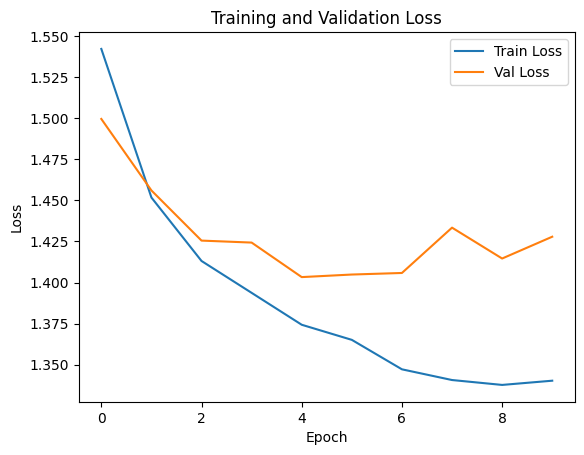

In [7]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

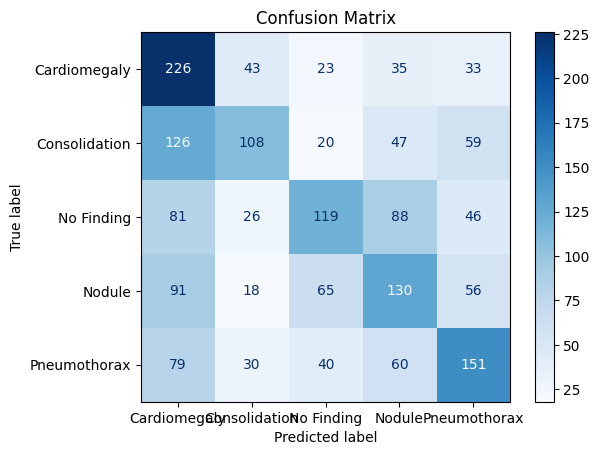

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

resnet.eval()
with torch.no_grad():
    for inputs, labels, labStr in val_loader:
        inputs = inputs.to(device)
        outputs = resnet(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()